In [38]:
# Packages
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import math


In [39]:
# Load data
def load_data(filepath):
    """Load data_file and split columns accordingly"""
    df = pd.read_csv(filepath, sep=",")
    t = df["t"].to_numpy()  # time
    X = df.filter(regex=r"^X\d+$").to_numpy()
    T, n = X.shape

    # Test of t and X
    assert np.array_equal(t, np.arange(1, T + 1))  # t = 1, ..., T
    assert (X >= 0).all()  # Check all X >= 0
    return df, t, X, T, n


def sanity_check_plot(t, X, n):
    fig, axes = plt.subplots(n + 1, 1, figsize=(10, 2 * (n + 1)), sharex=False, squeeze=False)

    for i in range(n):
        print(X[:i])
        axes[i, 0].plot(t, X[:, i], marker="o", markersize=2, linewidth=1)
        axes[i, 0].set_ylabel(f"X{i + 1}")

    axes[-1, 0].plot(t, X.mean(axis=1), linewidth=2)
    axes[-1, 0].set_ylabel("Mean")
    axes[-1, 0].set_label("t")

    plt.tight_layout()
    plt.show()


base_dir = os.getcwd()  # Local base directory
file_path = os.path.join(base_dir, "data", "Ex_1.csv")  # Filepath to csv file
df, t, X, T, n = load_data(file_path)
# print(f"Shape of X is: {(T, n)}")
# print(df.head())
# sanity_check_plot(t, X, n)


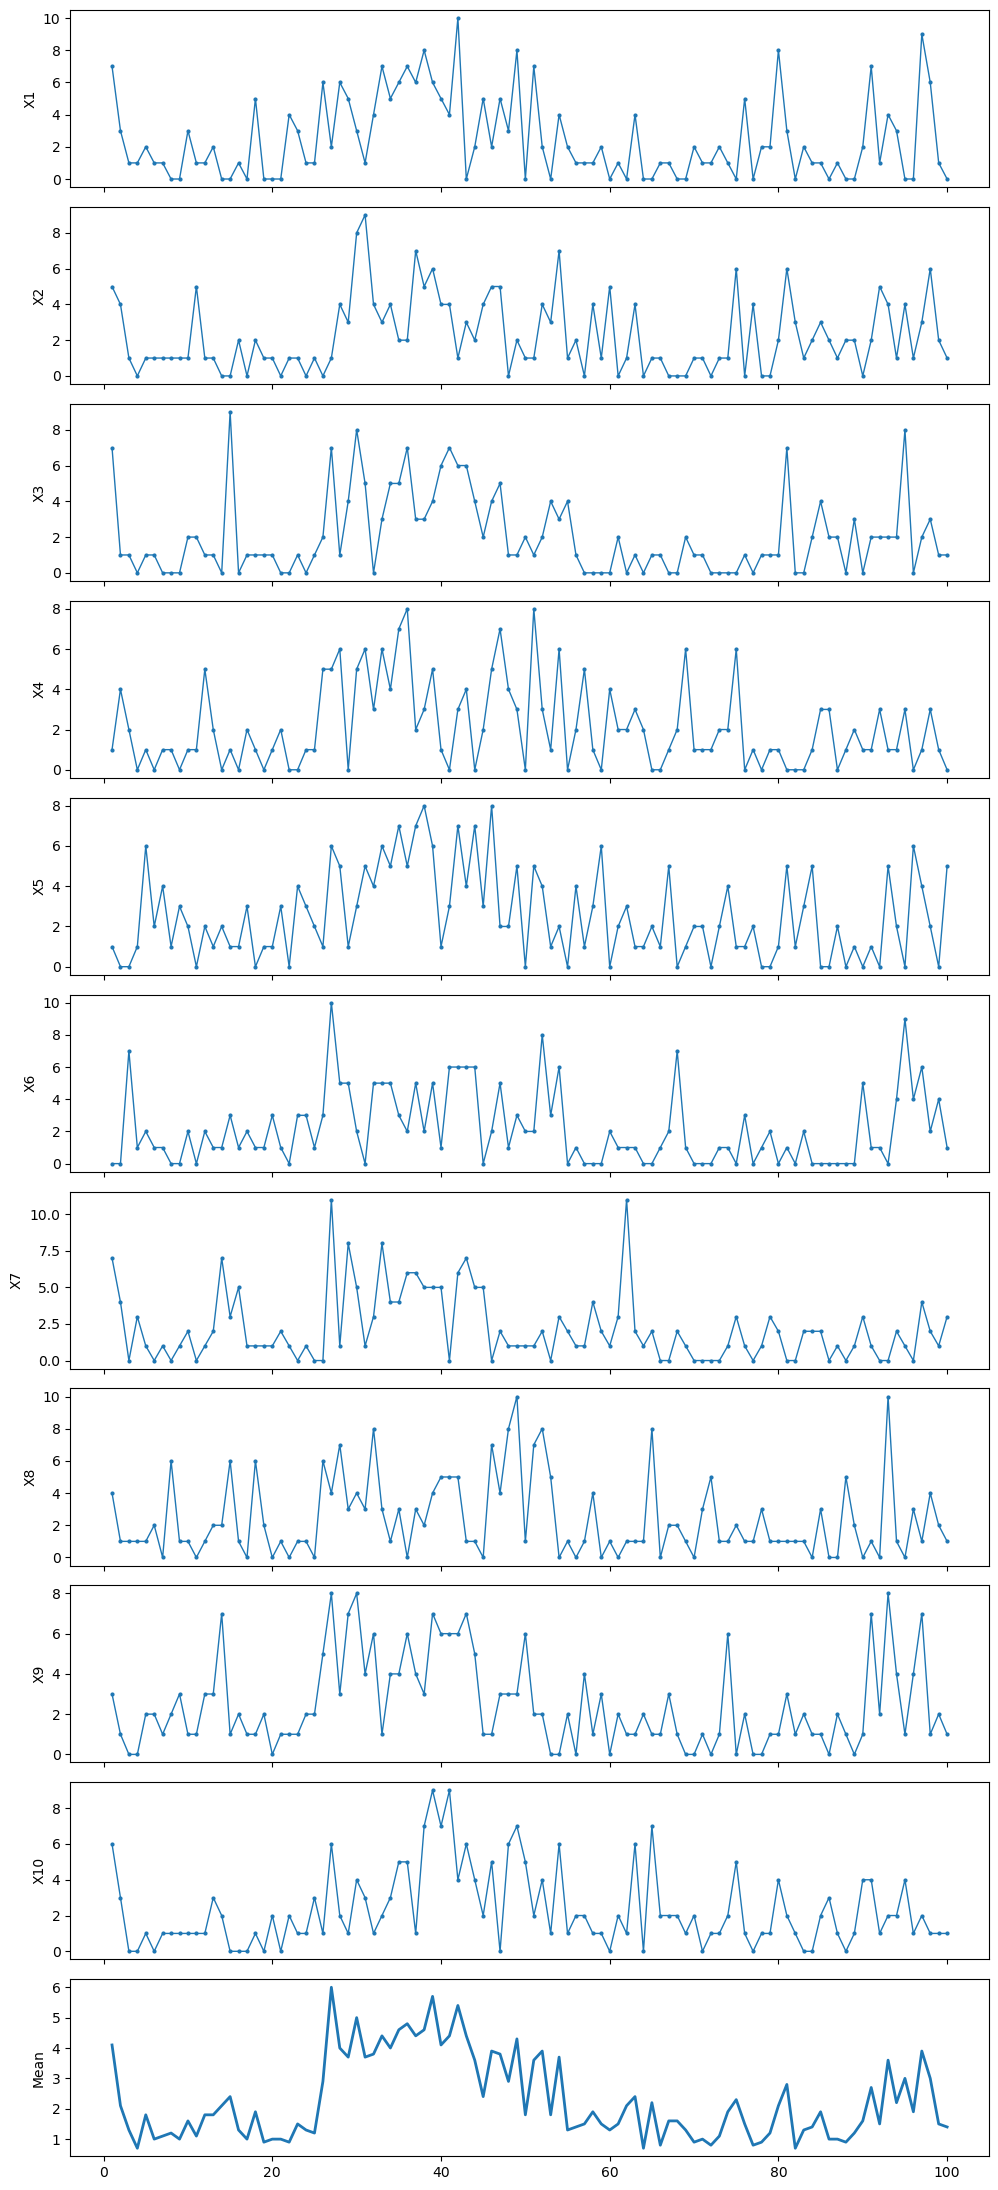

[[ 7  5  7  1  1  0  7  4  3  6]
 [ 3  4  1  4  0  0  4  1  1  3]
 [ 1  1  1  2  0  7  0  1  0  0]
 [ 1  0  0  0  1  1  3  1  0  0]
 [ 2  1  1  1  6  2  1  1  2  1]
 [ 1  1  1  0  2  1  0  2  2  0]
 [ 1  1  0  1  4  1  1  0  1  1]
 [ 0  1  0  1  1  0  0  6  2  1]
 [ 0  1  0  0  3  0  1  1  3  1]
 [ 3  1  2  1  2  2  2  1  1  1]
 [ 1  5  2  1  0  0  0  0  1  1]
 [ 1  1  1  5  2  2  1  1  3  1]
 [ 2  1  1  2  1  1  2  2  3  3]
 [ 0  0  0  0  2  1  7  2  7  2]
 [ 0  0  9  1  1  3  3  6  1  0]
 [ 1  2  0  0  1  1  5  1  2  0]
 [ 0  0  1  2  3  2  1  0  1  0]
 [ 5  2  1  1  0  1  1  6  1  1]
 [ 0  1  1  0  1  1  1  2  2  0]
 [ 0  1  1  1  1  3  1  0  0  2]
 [ 0  0  0  2  3  1  2  1  1  0]
 [ 4  1  0  0  0  0  1  0  1  2]
 [ 3  1  1  0  4  3  0  1  1  1]
 [ 1  0  0  1  3  3  1  1  2  1]
 [ 1  1  1  1  2  1  0  0  2  3]
 [ 6  0  2  5  1  3  0  6  5  1]
 [ 2  1  7  5  6 10 11  4  8  6]
 [ 6  4  1  6  5  5  1  7  3  2]
 [ 5  3  4  0  1  5  8  3  7  1]
 [ 3  8  8  5  3  2  5  4  8  4]
 [ 1  9  5

In [ ]:
def build_Gamma(beta, gamma):
    """Build the Gamma matrix"""
    if not (0 < beta < 1):
        raise ValueError(f"Beta must be between 0 and 1: Your input: {beta}")
    if not (0 < gamma < 1):
        raise ValueError(f"Gamma must be between 0 and 1. Your input: {gamma}")

    Gamma = np.array(
        [
            [1 - gamma, 0, gamma],
            [0, 1 - gamma, gamma],
            [beta / 2, beta / 2, 1 - beta],
        ]
    )
    return Gamma


def simulate_C(T, Gamma) -> list[int]:
    """Simulate the variables C_1,..., C_T ∈ {0, 1, 2}, which are
    state variables determining the probabilities of Z_{t,i} ∈ {0, 1} for all n neurons in time interval t.
    """
    C_t = [2]  # Definition C_1 = 2

    for _ in range(T - 1):
        u = np.random.rand()  # Generate a X ∼ Unif(0, 1)
        row = Gamma[C_t[-1]]  # Get the latest index
        p0, p1, _ = row  # Get the value of that index

        if u < p0:
            C_t.append(0)
        elif u < p0 + p1:
            C_t.append(1)
        else:
            C_t.append(2)
    return C_t


def simulate_Z(C, alpha, T, n):
    """Simulating the variables Z_{t,i} ∈ {0, 1}, which are the attention variables
    indicating if neuron i in time interval t is attending stimuli
    0 or 1"""
    if not (0.5 < alpha < 1):
        raise ValueError(f"Alpha must be a value between 0.5 and 1: Your input {alpha}")

    Z = np.empty(shape=(T, n), dtype=int)
    for t in range(T):
        if C[t] == 0:
            p_z1_given_c = 1 - alpha
        elif C[t] == 1:
            p_z1_given_c = alpha
        else:
            p_z1_given_c = 0.5

        for i in range(n):
            Z[t, i] = np.random.binomial(n=1, p=p_z1_given_c)
    return Z


def simulate_X(Z, lambda0, lambda1):
    if lambda0 < 0 or lambda1 < 0:
        raise ValueError("Both lambda0 and lambda1 most be bigger than 0")
    rates = np.where(Z == 0, lambda0, lambda1)
    X = np.random.poisson(lam=rates)
    return X


def illustrate_hidden_Markov_model(X, t, n):
    """Illustrate the implementation by generating example data and present them
    visually"""
    _, axes = plt.subplots(n + 1, 1, figsize=(10, 2 * (n + 1)), sharex=True, squeeze=False)

    for i in range(n):
        axes[i, 0].plot(t, X[:, i], marker="o", markersize=2, linewidth=1)
        axes[i, 0].set_ylabel(f"X{i + 1}")

    axes[-1, 0].plot(t, X.mean(axis=1), linewidth=2)
    axes[-1, 0].set_ylabel("Mean")
    axes[-1, 0].set_label("t")

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    # Model parameters
    T = 100  # Number of time steps
    t = np.arange(1, T + 1, 1)  # Times steps t = [1,..., T]
    beta = 0.2
    gamma = 0.1
    alpha = 0.9
    n = 10
    lambda0 = 1
    lambda1 = 5
    Gamma = build_Gamma(beta, gamma)

    # Simulate data
    C = simulate_C(T, Gamma)
    Z = simulate_Z(C, alpha, T, n)
    X = simulate_X(Z, lambda0=1, lambda1=5)

    illustrate_hidden_Markov_model(X, t, n)